Preparing Ground Truth Object...
Simulating capture of LR images with unknown 200.0 um defocus...

--- Starting Fast Auto-Focus Z-Sweep ---
Autofocus Complete! Optimal Z found at: 200.0 um

Running Full 30-iteration FPM using Z = 200.0 um...


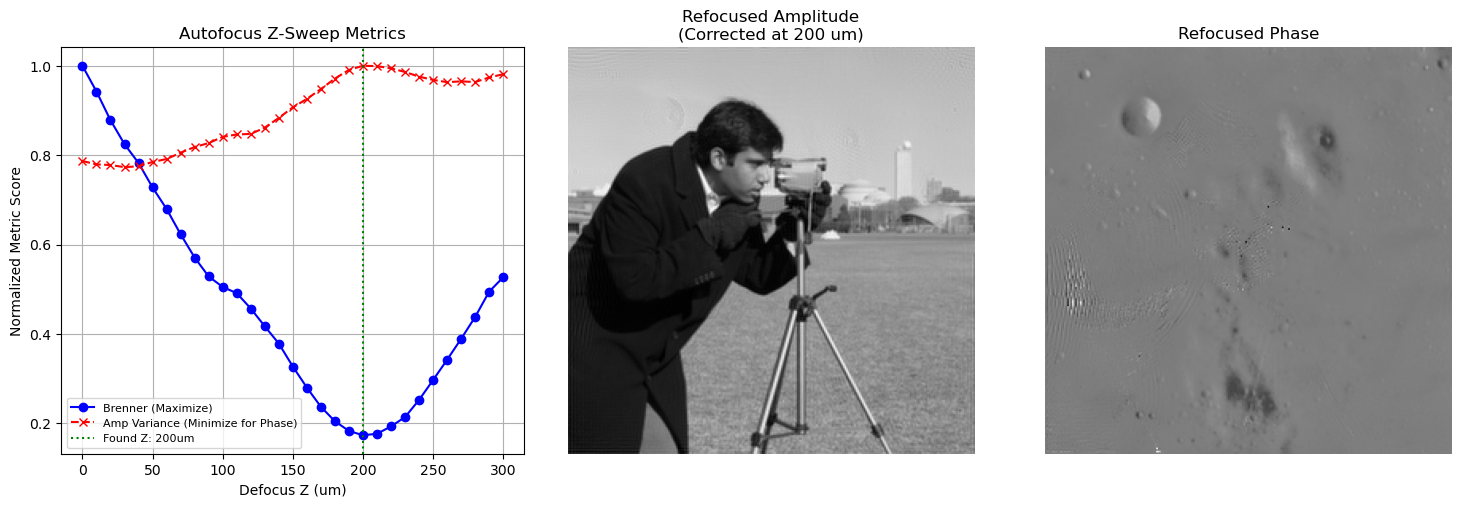

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, transform

def compute_focus_metrics(amp_image):
    """
    Computes focus metrics for a given amplitude image.
    1. Brenner Gradient (Maximizes at focus for amplitude features)
    2. Amplitude Variance/Modulation (Minimizes at focus for pure phase objects)
    """
    # Brenner gradient: square of differences between pixels separated by 2
    brenner = np.sum((amp_image[2:, :] - amp_image[:-2, :])**2)
    
    # Amplitude modulation: variance of the amplitude
    amp_modulation = np.var(amp_image)
    
    return brenner, amp_modulation

def simulate_autofocus_fpm():
    """
    Simulates defocused FPM data, runs a fast autofocus sweep to find z, 
    and then performs the final wavefront-corrected reconstruction.
    """
    # ==========================================
    # 1. System Parameters & Setup
    # ==========================================
    wavelength = 0.532e-3  # mm (532 nm)
    NA_obj = 0.08
    mag = 2.0
    
    led_grid_size = 7
    led_spacing = 4      # mm
    z_led = 60           # mm
    
    # The UNKNOWN physical defocus in the lab (150 um)
    actual_z_defocus = 200e-3
    
    cam_pixel_size = 6.5e-3 
    dx_lr = cam_pixel_size / mag 
    
    upsample_factor = 4
    N_lr = 64
    N_hr = N_lr * upsample_factor
    dx_hr = dx_lr / upsample_factor
    
    # ==========================================
    # 2. Ground Truth Object
    # ==========================================
    print("Preparing Ground Truth Object...")
    amp = transform.resize(data.camera(), (N_hr, N_hr), anti_aliasing=True)
    phase = transform.resize(data.moon(), (N_hr, N_hr), anti_aliasing=True)
    
    amp = amp / np.max(amp)
    phase = (phase / np.max(phase)) * np.pi
    obj_hr_gt = amp * np.exp(1j * phase)
    O_hr_gt = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(obj_hr_gt)))
    
    # ==========================================
    # 3. Spatial Frequencies & Forward Model
    # ==========================================
    fx_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    fy_lr = np.fft.fftshift(np.fft.fftfreq(N_lr, d=dx_lr))
    FX_lr, FY_lr = np.meshgrid(fx_lr, fy_lr)
    
    cutoff_freq = NA_obj / wavelength
    pupil_radius = np.sqrt(FX_lr**2 + FY_lr**2)
    pupil_ideal = (pupil_radius <= cutoff_freq).astype(float)
    
    # Calculate kz for defocus phase mapping
    radicand = np.maximum((1/wavelength)**2 - FX_lr**2 - FY_lr**2, 0)
    kz = 2 * np.pi * np.sqrt(radicand)
    
    print(f"Simulating capture of LR images with unknown {actual_z_defocus*1000} um defocus...")
    pupil_physical = pupil_ideal * np.exp(1j * actual_z_defocus * kz)
    
    led_idx = np.arange(-led_grid_size//2 + 1, led_grid_size//2 + 1)
    x_led, y_led = np.meshgrid(led_idx * led_spacing, led_idx * led_spacing)
    kx_led = (x_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    ky_led = (y_led / np.sqrt(x_led**2 + y_led**2 + z_led**2)) / wavelength
    
    I_measured = np.zeros((led_grid_size, led_grid_size, N_lr, N_lr))
    
    for i in range(led_grid_size):
        for j in range(led_grid_size):
            shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
            shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
            
            center_y, center_x = N_hr//2 + shift_y, N_hr//2 + shift_x
            y_start, y_end = center_y - N_lr//2, center_y + N_lr//2
            x_start, x_end = center_x - N_lr//2, center_x + N_lr//2
            
            if (y_start >= 0 and y_end <= N_hr and x_start >= 0 and x_end <= N_hr):
                O_sub = O_hr_gt[y_start:y_end, x_start:x_end]
            else:
                O_sub = np.zeros((N_lr, N_lr), dtype=np.complex128)
            
            E_lr_fourier = O_sub * pupil_physical
            E_lr_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_lr_fourier)))
            I_measured[i, j] = np.abs(E_lr_spatial)**2

    # ==========================================
    # 4. Fast Auto-Focusing Sweep Algorithm
    # ==========================================
    print("\n--- Starting Fast Auto-Focus Z-Sweep ---")
    # We sweep from 0 to 300 um in 10 um steps
    z_search_range = np.linspace(0.0, 0.300, 31) 
    brenner_scores = []
    amp_var_scores = []
    
    # To save time, only use the central 3x3 LEDs for the autofocus search
    center = led_grid_size // 2
    search_indices = [center-1, center, center+1]
    
    for z_test in z_search_range:
        # Create test pupil with current z guess
        pupil_test = pupil_ideal * np.exp(1j * z_test * kz)
        pupil_intensity = np.abs(pupil_test)**2
        max_pupil = np.max(pupil_intensity)
        
        # Initialize small reconstruction
        O_recon = np.zeros((N_hr, N_hr), dtype=np.complex128)
        initial_amp = np.sqrt(I_measured[center, center])
        O_recon[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
                N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
        
        # Run only 3 iterations on the 3x3 subset! (Blazing fast)
        for it in range(3):
            for i in search_indices:
                for j in search_indices:
                    shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                    shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                    
                    cy, cx = N_hr//2 + shift_y, N_hr//2 + shift_x
                    y_start, y_end = cy - N_lr//2, cy + N_lr//2
                    x_start, x_end = cx - N_lr//2, cx + N_lr//2
                    
                    O_sub = O_recon[y_start:y_end, x_start:x_end]
                    
                    E_est_fourier = O_sub * pupil_test
                    E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                    
                    amp_measured = np.sqrt(I_measured[i, j])
                    E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                    E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                    
                    update = (np.conj(pupil_test) / max_pupil) * (E_updated_fourier - E_est_fourier)
                    O_recon[y_start:y_end, x_start:x_end] += update
        
        # Evaluate metrics on the rapidly reconstructed amplitude
        obj_recon_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon)))
        amp_recon = np.abs(obj_recon_spatial)
        
        b_score, v_score = compute_focus_metrics(amp_recon)
        brenner_scores.append(b_score)
        amp_var_scores.append(v_score)

    # For our mixed object (Cameraman has strong amplitude edges), Brenner is the reliable metric.
    # If this was a purely transparent biological cell, we would minimize the amp_var_scores instead.
    best_z_idx = np.argmin(brenner_scores)
    optimal_z = z_search_range[best_z_idx]
    
    print(f"Autofocus Complete! Optimal Z found at: {optimal_z*1000:.1f} um")
    
    # ==========================================
    # 5. Full Final Reconstruction with Optimal Z
    # ==========================================
    print(f"\nRunning Full 30-iteration FPM using Z = {optimal_z*1000:.1f} um...")
    pupil_optimal = pupil_ideal * np.exp(1j * optimal_z * kz)
    pupil_intensity = np.abs(pupil_optimal)**2
    max_pupil = np.max(pupil_intensity)
    
    O_recon_final = np.zeros((N_hr, N_hr), dtype=np.complex128)
    initial_amp = np.sqrt(I_measured[center, center])
    O_recon_final[N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2, 
                  N_hr//2 - N_lr//2 : N_hr//2 + N_lr//2] = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(initial_amp)))
    
    # Full loop (49 LEDs, 30 Iterations)
    for it in range(30):
        for i in range(led_grid_size):
            for j in range(led_grid_size):
                shift_x = int(np.round(kx_led[i, j] * N_hr * dx_hr))
                shift_y = int(np.round(ky_led[i, j] * N_hr * dx_hr))
                
                cy, cx = N_hr//2 + shift_y, N_hr//2 + shift_x
                y_start, y_end = cy - N_lr//2, cy + N_lr//2
                x_start, x_end = cx - N_lr//2, cx + N_lr//2
                
                if (y_start < 0 or y_end > N_hr or x_start < 0 or x_end > N_hr):
                    continue
                
                O_sub = O_recon_final[y_start:y_end, x_start:x_end]
                
                E_est_fourier = O_sub * pupil_optimal
                E_est_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(E_est_fourier)))
                
                amp_measured = np.sqrt(I_measured[i, j])
                E_updated_spatial = amp_measured * np.exp(1j * np.angle(E_est_spatial))
                E_updated_fourier = np.fft.fftshift(np.fft.fft2(np.fft.ifftshift(E_updated_spatial)))
                
                update = (np.conj(pupil_optimal) / max_pupil) * (E_updated_fourier - E_est_fourier)
                O_recon_final[y_start:y_end, x_start:x_end] += update
                
    final_spatial = np.fft.fftshift(np.fft.ifft2(np.fft.ifftshift(O_recon_final)))
    final_amp = np.abs(final_spatial)
    final_phase = np.angle(final_spatial)

    # ==========================================
    # 6. Visualization
    # ==========================================
    plt.figure(figsize=(15, 5))
    
    # Plot 1: Autofocus Metrics
    plt.subplot(1, 3, 1)
    plt.title("Autofocus Z-Sweep Metrics")
    # Normalize for comparison
    norm_brenner = np.array(brenner_scores) / np.max(brenner_scores)
    norm_amp_var = np.array(amp_var_scores) / np.max(amp_var_scores)
    
    plt.plot(z_search_range * 1000, norm_brenner, 'b-o', label='Brenner (Maximize)')
    plt.plot(z_search_range * 1000, norm_amp_var, 'r--x', label='Amp Variance (Minimize for Phase)')
    plt.axvline(optimal_z * 1000, color='g', linestyle=':', label=f'Found Z: {optimal_z*1000:.0f}um')
    plt.xlabel("Defocus Z (um)")
    plt.ylabel("Normalized Metric Score")
    plt.legend(fontsize=8)
    plt.grid(True)
    
    # Plot 2: Final Amplitude
    plt.subplot(1, 3, 2)
    plt.title(f"Refocused Amplitude\n(Corrected at {optimal_z*1000:.0f} um)")
    plt.imshow(final_amp, cmap='gray')
    plt.axis('off')
    
    # Plot 3: Final Phase
    plt.subplot(1, 3, 3)
    plt.title("Refocused Phase")
    plt.imshow(final_phase, cmap='gray')
    plt.axis('off')
    
    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    simulate_autofocus_fpm()